In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:

pasta_dados = Path("DadosBrutos") if Path("DadosBrutos").exists() else Path("..") / "DadosBrutos"
caminho_arquivo = pasta_dados / "V_EXPORTACAO_.csv"
df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig')

colunas_texto = ['Países', 'Descrição NCM']
for col in colunas_texto:
    df[col] = df[col].str.replace(r'[\r\n]+', ' ', regex=True).str.strip()

df.head(10)

,Ano,Código NCM,Descrição NCM,Países,Valor US$ FOB,Quilograma Líquido
0,2025,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Angola,122025306,260663908
1,2025,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Cabo Verde,5050904,11062770
2,2025,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Tomé e Príncipe,1383827,2970000
3,2025,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Guiné-Bissau,870370,1772000
4,2025,21039029,"Outros condimentos e temperos, compostos",Angola,851720,254456
5,2025,19019090,"Outras preparações alimentícias de farinhas, e...",Cabo Verde,459115,263707
6,2025,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Moçambique,414674,833000
7,2025,17049020,"Caramelos, confeitos, dropes, pastilhas, e pro...",Angola,376909,251150
8,2025,20098990,"Sucos (sumo) de outras frutas, não fermentado,...",Cabo Verde,226939,171201
9,2025,20098990,"Sucos (sumo) de outras frutas, não fermentado,...",Moçambique,165000,150000


In [3]:
print(df.shape)
print(df.dtypes)

(962, 6)
Ano                    int64
Código NCM             int64
Descrição NCM         object
Países                object
Valor US$ FOB          int64
Quilograma Líquido     int64
dtype: object


## 2. Corrigir o Código NCM

O NCM tem 8 dígitos e alguns começam com `0`. Como o pandas lê a coluna como número,
esse zero se perde.

In [4]:
print(df['Código NCM'].astype(str).str.len().value_counts())

Código NCM
8    831
7    131
Name: count, dtype: int64


In [5]:
df['Código NCM'] = df['Código NCM'].astype(str).str.zfill(8)

print(df['Código NCM'].str.len().value_counts())
print("NCMs distintos no extrato:", df['Código NCM'].nunique())

Código NCM
8    962
Name: count, dtype: int64
NCMs distintos no extrato: 49


In [6]:
VALOR_MINIMO = 500   # US$ FOB por ano; abaixo disso não é operação comercial

primeiro_ano = df['Ano'].min()
ultimo_ano = df['Ano'].max()
anos_base = list(range(primeiro_ano, ultimo_ano + 1))

paises_palop = ['Angola', 'Cabo Verde', 'Guiné-Bissau', 'Moçambique', 'São Tomé e Príncipe']

ncms = sorted(df['Código NCM'].unique())


# 1) cria uma lista de zeros (um por ano) para cada par (NCM, país)
series = {}
for ncm in ncms:
    for pais in paises_palop:
        zeros = []
        for ano in anos_base:
            zeros.append(0)
        series[(ncm, pais)] = zeros


# 2) percorre o CSV e soma cada valor na posição do ano
for i in range(len(df)):
    ncm = df.loc[i, 'Código NCM']
    pais = df.loc[i, 'Países']
    ano = df.loc[i, 'Ano']
    valor = df.loc[i, 'Valor US$ FOB']

    if pais in paises_palop:
        posicao = anos_base.index(ano)
        series[(ncm, pais)][posicao] = series[(ncm, pais)][posicao] + valor


# 3) zera os anos abaixo do valor mínimo
removidos = 0
for chave in series:
    valores = series[chave]
    for i in range(len(valores)):
        if valores[i] > 0 and valores[i] < VALOR_MINIMO:
            valores[i] = 0
            removidos = removidos + 1


# 4) transforma o dicionário em DataFrame
linhas = []
chaves = []
for chave in series:
    chaves.append(chave)
    linhas.append(series[chave])

indice = pd.MultiIndex.from_tuples(chaves, names=['Código NCM', 'Países'])
tabela = pd.DataFrame(linhas, columns=anos_base, index=indice)


print("Anos:", primeiro_ano, "a", ultimo_ano)
print("NCMs:", len(ncms))
print("Linhas esperadas:", len(ncms) * len(paises_palop))
print("Linhas na tabela:", tabela.shape[0])
print("Registros removidos pelo corte:", removidos)
tabela.head(20)

Anos: 2014 a 2025
NCMs: 49
Linhas esperadas: 245
Linhas na tabela: 245
Registros removidos pelo corte: 243


2014  2015  2016  2017  2018  2019   2020  \
Código NCM Países                                                            
07129090   Angola                   0   731     0     0     0     0      0   
           Cabo Verde               0     0     0     0     0     0      0   
           Guiné-Bissau             0     0     0     0     0     0      0   
           Moçambique               0     0     0     0     0     0      0   
           São Tomé e Príncipe      0     0     0     0     0     0      0   
08011100   Angola                   0  1736  4315  5336  4938  5691  27942   
           Cabo Verde               0     0  1371     0   690  2826   1006   
           Guiné-Bissau             0     0     0     0     0     0      0   
           Moçambique             967     0     0     0     0     0      0   
           São Tomé e Príncipe      0     0     0     0     0     0      0   
09041100   Angola                1199     0     0     0     0     0      0   
           Cabo Verde               0     0     0     0     0     0      0   
           Guiné-Bissau             0     0     0     0     0     0      0   
           Moçambique               0     0     0     0     0     0      0   
           São Tomé e Príncipe      0     0     0     0     0     0      0   
09041200   Angola               74564  7691     0     0     0     0   1547   
           Cabo Verde               0     0     0     0     0     0      0   
           Guiné-Bissau             0     0     0     0     0     0      0   
           Moçambique               0     0     0     0     0     0      0   
           São Tomé e Príncipe      0     0     0     0     0     0      0   

                                2021   2022  2023  2024  2025  
Código NCM Países                                              
07129090   Angola                  0      0     0  2985     0  
           Cabo Verde              0      0     0     0     0  
           Guiné-Bissau            0      0     0     0     0  
           Moçambique              0      0     0     0     0  
           São Tomé e Príncipe     0      0     0     0     0  
08011100   Angola               6026  30087     0  4452  6701  
           Cabo Verde              0      0  1534     0     0  
           Guiné-Bissau            0      0     0     0     0  
           Moçambique              0      0     0     0     0  
           São Tomé e Príncipe     0      0     0     0     0  
09041100   Angola                  0      0     0     0     0  
           Cabo Verde              0      0     0     0     0  
           Guiné-Bissau            0      0     0     0     0  
           Moçambique              0      0     0     0     0  
           São Tomé e Príncipe     0      0     0     0     0  
09041200   Angola               1708   5372  2140     0     0  
           Cabo Verde              0      0     0     0     0  
           Guiné-Bissau            0      0     0     0     0  
           Moçambique              0      0     0     0     0  
           São Tomé e Príncipe     0      0     0     0     0

In [7]:
# inclinação da reta: usada no caso continuidade
def calcular_inclinacao(anos, valores):
    inclinacao, intercepto = np.polyfit(anos, valores, 1)
    return inclinacao


# quantos anos exportou: usado em surgimento e intermitente
def contar_anos_ativos(valores):
    total = 0
    for valor in valores:
        if valor > 0:
            total = total + 1
    return total


# último ano com exportação: usado em descontinuidade
def achar_ano_final(anos, valores):
    ano_final = None
    for i in range(len(valores)):
        if valores[i] > 0:
            ano_final = anos[i]
    return ano_final

## 5. Os 4 casos

- **Continuidade**: exportou em todos os anos da base. Melhor = o que mais cresce.
- **Surgimento**: começou depois do primeiro ano e segue até o último, sem buracos.
  Melhor = o que começou mais cedo.
- **Descontinuidade**: exportou desde o primeiro ano, mas parou antes do último.
  Melhor = o que parou mais recentemente.
- **Intermitente**: exportou, mas com buracos na série. Melhor = o que apareceu em mais anos.


In [8]:
MIN_ANOS_SURGIMENTO = 2


def eh_continua(valores):
    for valor in valores:
        if valor == 0:
            return False
    return True


def eh_surgimento(valores):
    if valores[0] > 0:
        return False
    if valores[-1] == 0:
        return False
    if contar_anos_ativos(valores) < MIN_ANOS_SURGIMENTO:
        return False

    achou_inicio = False
    for valor in valores:
        if valor > 0:
            achou_inicio = True
        elif achou_inicio:
            return False

    return True


def eh_descontinuidade(valores):
    if valores[0] == 0:
        return False
    if valores[-1] > 0:
        return False

    achou_zero = False
    for valor in valores:
        if valor == 0:
            achou_zero = True
        elif achou_zero:
            return False

    return True


def eh_intermitente(valores):
    if eh_continua(valores):
        return False
    if eh_surgimento(valores):
        return False
    if eh_descontinuidade(valores):
        return False

    for valor in valores:
        if valor > 0:
            return True

    return False


def classificar(valores):
    if eh_continua(valores):
        return "continuidade"
    if eh_surgimento(valores):
        return "surgimento"
    if eh_descontinuidade(valores):
        return "descontinuidade"
    if eh_intermitente(valores):
        return "intermitente"
    return "nunca exportou"

## 6. Classificar todos os pares

In [9]:
descricoes = df.groupby('Código NCM')['Descrição NCM'].first()

linhas = []
for (ncm, pais), linha in tabela.iterrows():
    valores = linha.tolist()
    caso = classificar(valores)

    inclinacao = None
    if caso == "continuidade":
        inclinacao = calcular_inclinacao(anos_base, valores)

    ano_final = None
    if caso == "descontinuidade":
        ano_final = achar_ano_final(anos_base, valores)

    linhas.append({
        'Código NCM': ncm,
        'Descrição NCM': descricoes[ncm],
        'Países': pais,
        'caso': caso,
        'anos_ativos': contar_anos_ativos(valores),
        'inclinacao': inclinacao,
        'ano_final': ano_final,
        'FOB_total': sum(valores),
    })

resultado = pd.DataFrame(linhas)
print(resultado.shape)
resultado.head(20)

(245, 8)


,Código NCM,Descrição NCM,Países,caso,anos_ativos,inclinacao,ano_final,FOB_total
0,07129090,Outros produtos hortícolas; misturas de produt...,Angola,intermitente,2,NaN,NaN,3716
1,07129090,Outros produtos hortícolas; misturas de produt...,Cabo Verde,nunca exportou,0,NaN,NaN,0
2,07129090,Outros produtos hortícolas; misturas de produt...,Guiné-Bissau,nunca exportou,0,NaN,NaN,0
3,07129090,Outros produtos hortícolas; misturas de produt...,Moçambique,nunca exportou,0,NaN,NaN,0
4,07129090,Outros produtos hortícolas; misturas de produt...,São Tomé e Príncipe,nunca exportou,0,NaN,NaN,0
5,08011100,"Cocos, frescos ou secos, dessecados",Angola,intermitente,10,NaN,NaN,97224
6,08011100,"Cocos, frescos ou secos, dessecados",Cabo Verde,intermitente,5,NaN,NaN,7427
7,08011100,"Cocos, frescos ou secos, dessecados",Guiné-Bissau,nunca exportou,0,NaN,NaN,0
8,08011100,"Cocos, frescos ou secos, dessecados",Moçambique,descontinuidade,1,NaN,2014.0,967
9,08011100,"Cocos, frescos ou secos, dessecados",São Tomé e Príncipe,nunca exportou,0,NaN,NaN,0


## 7. Panorama geral

In [10]:
print(resultado['caso'].value_counts())

caso
nunca exportou     125
intermitente        82
continuidade        23
descontinuidade      8
surgimento           7
Name: count, dtype: int64


In [11]:
pd.crosstab(resultado['Países'], resultado['caso'])

caso,continuidade,descontinuidade,intermitente,nunca exportou,surgimento
Países,,,,,
Angola,11,4,28,5,1
Cabo Verde,9,1,19,18,2
Guiné-Bissau,1,0,6,42,0
Moçambique,2,3,21,21,2
São Tomé e Príncipe,0,0,8,39,2


In [12]:
# os pares em continuidade, do que mais cresce para o que mais cai
resultado[resultado['caso'] == 'continuidade'].sort_values('inclinacao', ascending=False)

,Código NCM,Descrição NCM,Países,caso,anos_ativos,inclinacao,ano_final,FOB_total
116,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Cabo Verde,continuidade,12,4.155935e+04,NaN,63298939
181,20098990,"Sucos (sumo) de outras frutas, não fermentado,...",Cabo Verde,continuidade,12,1.448557e+04,NaN,1174207
121,17049020,"Caramelos, confeitos, dropes, pastilhas, e pro...",Cabo Verde,continuidade,12,1.257869e+04,NaN,1867826
156,19023000,Outras massas alimentícias,Cabo Verde,continuidade,12,4.479336e+03,NaN,645966
145,19019090,"Outras preparações alimentícias de farinhas, e...",Angola,continuidade,12,3.627927e+03,NaN,448515
136,18069000,Outros chocolates e preparações alimentícias c...,Cabo Verde,continuidade,12,2.334832e+03,NaN,540344
153,19021900,"Outras massas alimentícias não cozidas, nem re...",Moçambique,continuidade,12,5.375734e+02,NaN,162472
155,19023000,Outras massas alimentícias,Angola,continuidade,12,8.226224e+01,NaN,111403
130,18061000,"Cacau em pó, com adição de açúcar ou outros ed...",Angola,continuidade,12,-4.779476e+02,NaN,83685
215,21069010,Outras preparações para elaboração de bebidas,Angola,continuidade,12,-6.392308e+02,NaN,563590


## 8. Gráfico de um par específico

Caso: surgimento


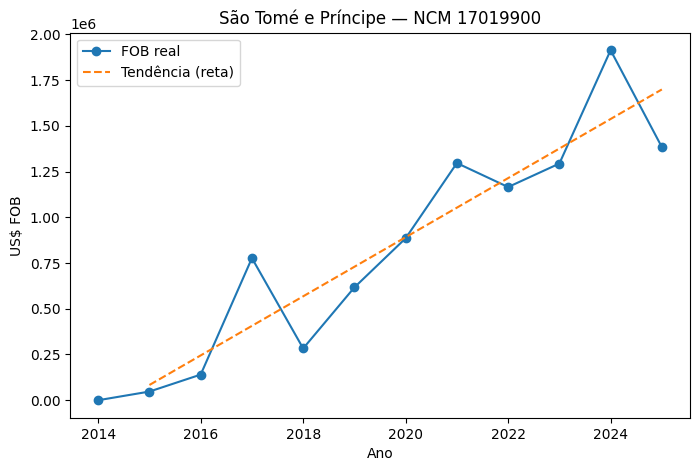

In [13]:
def plotar_tendencia(ncm, pais):
    valores = tabela.loc[(ncm, pais)].tolist()

    anos_ativos = []
    valores_ativos = []
    for i in range(len(valores)):
        if valores[i] > 0:
            anos_ativos.append(anos_base[i])
            valores_ativos.append(valores[i])

    plt.figure(figsize=(8, 5))
    plt.plot(anos_base, valores, marker='o', label='FOB real')

    if len(anos_ativos) >= 2:
        inclinacao, intercepto = np.polyfit(anos_ativos, valores_ativos, 1)
        linha_tendencia = []
        for ano in anos_ativos:
            linha_tendencia.append(inclinacao * ano + intercepto)
        plt.plot(anos_ativos, linha_tendencia, linestyle='--', label='Tendência (reta)')

    print("Caso:", classificar(valores))
    plt.title(pais + " — NCM " + ncm)
    plt.xlabel("Ano")
    plt.ylabel("US$ FOB")
    plt.legend()
    plt.show()


plotar_tendencia('17019900', 'São Tomé e Príncipe')

In [14]:
PESO_BASE = {
    "continuidade": 3.0,
    "surgimento": 2.5,
    "descontinuidade": 1.5,
    "intermitente": 1.0,
    "nunca exportou": 0.0,
}
MARGEM = 0.8


def calcular_metrica(caso, anos, valores):
    if caso == "continuidade":
        return calcular_inclinacao(anos, valores)
    if caso == "surgimento":
        return contar_anos_ativos(valores)
    if caso == "descontinuidade":
        return achar_ano_final(anos, valores)
    if caso == "intermitente":
        return contar_anos_ativos(valores)
    return 0


def posicao_relativa(valor, ordenados):
    if len(ordenados) == 1:
        return 0.5
    return ordenados.index(valor) / (len(ordenados) - 1)


todos = []
for (ncm, pais), linha in tabela.iterrows():
    valores = linha.tolist()
    caso = classificar(valores)
    todos.append({
        'ncm': ncm,
        'pais': pais,
        'caso': caso,
        'metrica': calcular_metrica(caso, anos_base, valores),
    })

metricas_por_caso = {}
for item in todos:
    caso = item['caso']
    if caso not in metricas_por_caso:
        metricas_por_caso[caso] = []
    metricas_por_caso[caso].append(item['metrica'])

for caso in metricas_por_caso:
    metricas_por_caso[caso].sort()

for item in todos:
    caso = item['caso']
    if caso == "nunca exportou":
        item['score'] = 0.0
    else:
        relativo = posicao_relativa(item['metrica'], metricas_por_caso[caso])
        item['score'] = PESO_BASE[caso] + relativo * MARGEM

print("Pares:", len(todos))
for caso in metricas_por_caso:
    print(caso, "->", len(metricas_por_caso[caso]), "pares")

Pares: 245
intermitente -> 82 pares
nunca exportou -> 125 pares
descontinuidade -> 8 pares
surgimento -> 7 pares
continuidade -> 23 pares


In [15]:
linhas_ranking = []
for item in todos:
    linhas_ranking.append({
        'Código NCM': item['ncm'],
        'Descrição NCM': descricoes[item['ncm']],
        'Países': item['pais'],
        'caso': item['caso'],
        'score': round(item['score'], 3),
    })

ranking = pd.DataFrame(linhas_ranking)

# posição dentro de cada NCM
ranking = ranking.sort_values(['Código NCM', 'score'], ascending=[True, False])
ranking['posicao'] = ranking.groupby('Código NCM').cumcount() + 1

print(ranking.shape)
ranking.head(10)

(245, 6)


,Código NCM,Descrição NCM,Países,caso,score,posicao
0,07129090,Outros produtos hortícolas; misturas de produt...,Angola,intermitente,1.227,1
1,07129090,Outros produtos hortícolas; misturas de produt...,Cabo Verde,nunca exportou,0.000,2
2,07129090,Outros produtos hortícolas; misturas de produt...,Guiné-Bissau,nunca exportou,0.000,3
3,07129090,Outros produtos hortícolas; misturas de produt...,Moçambique,nunca exportou,0.000,4
4,07129090,Outros produtos hortícolas; misturas de produt...,São Tomé e Príncipe,nunca exportou,0.000,5
5,08011100,"Cocos, frescos ou secos, dessecados",Angola,intermitente,1.681,1
6,08011100,"Cocos, frescos ou secos, dessecados",Cabo Verde,intermitente,1.514,2
8,08011100,"Cocos, frescos ou secos, dessecados",Moçambique,descontinuidade,1.500,3
7,08011100,"Cocos, frescos ou secos, dessecados",Guiné-Bissau,nunca exportou,0.000,4
9,08011100,"Cocos, frescos ou secos, dessecados",São Tomé e Príncipe,nunca exportou,0.000,5


## 10. Consultas

In [16]:
# ranking de um produto específico
ranking[ranking['Código NCM'] == '17019900']

,Código NCM,Descrição NCM,Países,caso,score,posicao
116,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Cabo Verde,continuidade,3.800,1
119,17019900,"Outros açúcares de cana, beterraba, sacarose q...",São Tomé e Príncipe,surgimento,3.167,2
117,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Guiné-Bissau,continuidade,3.109,3
115,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Angola,continuidade,3.000,4
118,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Moçambique,intermitente,1.622,5


In [17]:
# quantas vezes cada país ficou em primeiro lugar
ranking[ranking['posicao'] == 1]['Países'].value_counts()

Países
Angola        36
Cabo Verde    11
Moçambique     2
Name: count, dtype: int64

In [18]:
ranking.sort_values('score', ascending=False).head(20)

,Código NCM,Descrição NCM,Países,caso,score,posicao
116,17019900,"Outros açúcares de cana, beterraba, sacarose q...",Cabo Verde,continuidade,3.800,1
181,20098990,"Sucos (sumo) de outras frutas, não fermentado,...",Cabo Verde,continuidade,3.764,1
121,17049020,"Caramelos, confeitos, dropes, pastilhas, e pro...",Cabo Verde,continuidade,3.727,1
156,19023000,Outras massas alimentícias,Cabo Verde,continuidade,3.691,1
145,19019090,"Outras preparações alimentícias de farinhas, e...",Angola,continuidade,3.655,1
136,18069000,Outros chocolates e preparações alimentícias c...,Cabo Verde,continuidade,3.618,1
153,19021900,"Outras massas alimentícias não cozidas, nem re...",Moçambique,continuidade,3.582,1
155,19023000,Outras massas alimentícias,Angola,continuidade,3.545,2
130,18061000,"Cacau em pó, com adição de açúcar ou outros ed...",Angola,continuidade,3.509,1
215,21069010,Outras preparações para elaboração de bebidas,Angola,continuidade,3.473,1
